# Predicting 30-Day Hospital Readmission in Patients with Diabetes
**Random Forest + SHAP**

This notebook builds a model that predicts whether a patient with diabetes will be readmitted within 30 days of discharge, compares it with a logistic regression baseline, and uses SHAP to show which features the Random Forest relies on.

**Data:** [Diabetes 130-US Hospitals for Years 1999–2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (UCI Machine Learning Repository). To re-run, download `diabetic_data.csv` and place it in the same folder as this notebook.

**Sections:** 1. Cohort, features, Random Forest and SHAP · 2. Logistic regression baseline · 3. Software versions

## 1. Cohort, features, Random Forest and SHAP
- Keep only each patient's **first** encounter, then exclude deaths and hospice discharges (cohort: 101,766 → 71,518 → 69,973 patients).
- Outcome: readmitted within 30 days (1) versus not (0).
- Drop `weight`, `payer_code` and `medical_specialty` (extensive missing values); treat admission/discharge ID codes as categories; one-hot encode.
- Stratified 80/20 train–test split; Random Forest with balanced class weights.
- SHAP beeswarm plot for a random sample of 500 test patients, saved to `figures/shap_beeswarm.png`.

AUC: 0.633
              precision    recall  f1-score   support

           0       0.93      0.69      0.79     12740
           1       0.14      0.50      0.21      1255

    accuracy                           0.67     13995
   macro avg       0.53      0.59      0.50     13995
weighted avg       0.86      0.67      0.74     13995



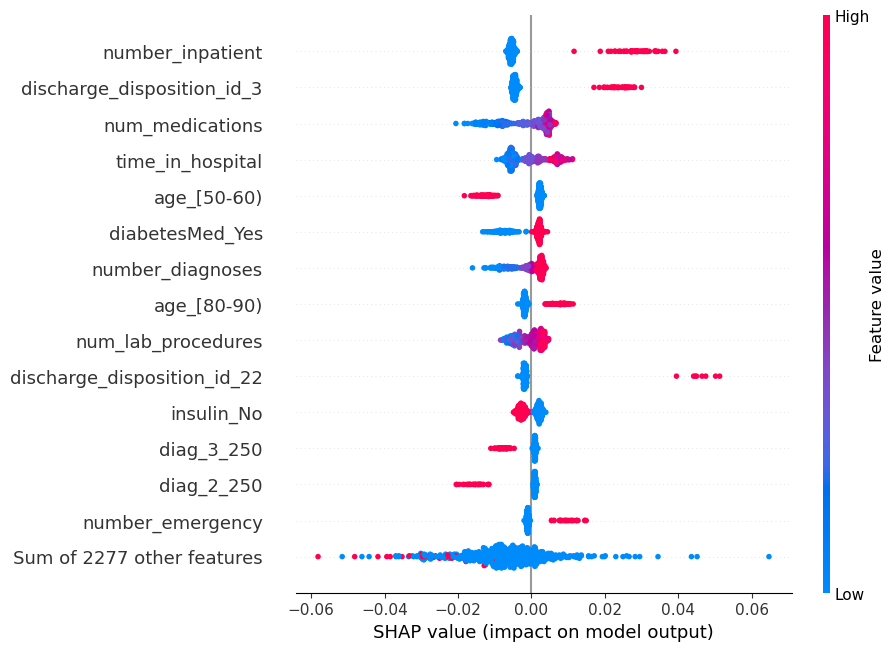

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import shap
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('diabetic_data.csv')

# 2. Keep each patient's first encounter
df_sorted = df.sort_values('encounter_id')
df_unique = df_sorted.drop_duplicates(subset=['patient_nbr'], keep='first')

# 3. Exclude deaths and hospice discharges
dead_end_ids = [11, 13, 14, 19, 20, 21]
df_clean = df_unique[~df_unique['discharge_disposition_id'].isin(dead_end_ids)].copy()

# 4. Target: readmitted within 30 days
df_clean['target'] = (df_clean['readmitted'] == '<30').astype(int)

# 5. Drop sparse columns, then encode
columns_to_drop = ['weight', 'payer_code', 'medical_specialty', 'readmitted']
df_final = df_clean.drop(columns=columns_to_drop)
X_raw = df_final.drop(columns=['target', 'patient_nbr', 'encounter_id'])
y = df_final['target']

# Treat ID codes as categories, not numbers
id_cols = ['admission_type_id', 'admission_source_id', 'discharge_disposition_id']
X_raw[id_cols] = X_raw[id_cols].astype(str)

X_encoded = pd.get_dummies(X_raw, drop_first=True)

# 6. Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 7. Train
model = RandomForestClassifier(n_estimators=100, max_depth=10,
                               random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Performance metrics
y_prob = model.predict_proba(X_test)[:, 1]
print("AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(classification_report(y_test, model.predict(X_test)))

# 8. SHAP
explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer(X_sample)

# Use class 1 (readmitted within 30 days), then save the figure before showing it
sv = shap_values[:, :, 1] if shap_values.values.ndim == 3 else shap_values

os.makedirs("figures", exist_ok=True)
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.savefig("figures/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Baseline: logistic regression
A simple standard model on the same train–test split, used to judge whether the Random Forest adds anything.

In [2]:
from scipy import sparse
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, classification_report

Xtr = sparse.csr_matrix(X_train.astype("float32").values)
Xte = sparse.csr_matrix(X_test.astype("float32").values)

baseline = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"),
)
baseline.fit(Xtr, y_train)

prob = baseline.predict_proba(Xte)[:, 1]
print("Baseline AUC:", round(roc_auc_score(y_test, prob), 3))
print(classification_report(y_test, baseline.predict(Xte)))

Baseline AUC: 0.624
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     12740
           1       0.14      0.53      0.22      1255

    accuracy                           0.66     13995
   macro avg       0.54      0.60      0.50     13995
weighted avg       0.86      0.66      0.73     13995



## 3. Software versions

In [3]:
import sys, sklearn, shap, pandas, matplotlib
print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.12.12
scikit-learn: 1.7.2
SHAP: 0.52.0
pandas: 2.3.3
matplotlib: 3.10.6
